In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In [2]:
# Path of dataset in Z drive
file_path = "C:/Users/Kandarp Malkan/OneDrive/Desktop/DL_Material/placement.csv"
# file_path = "Z:/placement.csv" FOR THE LAB/ EXAM ENVIRONMENT

# Load CSV file
df = pd.read_csv(file_path)

# Display first 5 rows
df.head()

,CGPA,IQ,EQ,Package
0,6.87,93,88,10.06
1,9.75,118,87,13.83
2,8.66,141,133,16.16
3,7.99,131,87,10.80
4,5.78,136,89,12.32


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape: (1000, 4)

Column Names:
Index(['CGPA', 'IQ', 'EQ', 'Package'], dtype='object')

First 5 Rows:
   CGPA   IQ   EQ  Package
0  6.87   93   88    10.06
1  9.75  118   87    13.83
2  8.66  141  133    16.16
3  7.99  131   87    10.80
4  5.78  136   89    12.32


In [4]:
X = df[["CGPA", "IQ", "EQ"]]

y = df["Package"]

print("Input features:")
print(X.head())

print("\nTarget:")
print(y.head())

Input features:
   CGPA   IQ   EQ
0  6.87   93   88
1  9.75  118   87
2  8.66  141  133
3  7.99  131   87
4  5.78  136   89

Target:
0    10.06
1    13.83
2    16.16
3    10.80
4    12.32
Name: Package, dtype: float64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 3)
Testing data: (200, 3)


In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [7]:
model = tf.keras.Sequential([
    
    tf.keras.layers.Input(shape=(3,)),
    
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(1, activation="linear")
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 16)                64        
                                                                 
 dense_1 (Dense)             (None, 8)                 136       
                                                                 
 dense_2 (Dense)             (None, 1)                 9         
                                                                 
Total params: 209
Trainable params: 209
Non-trainable params: 0
_________________________________________________________________


In [8]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mse"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [9]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=20,
    batch_size=16,
    verbose=1
)

Epoch 1/20
40/40 [==============================] - 1s 8ms/step - loss: 130.1460 - mse: 130.1460 - val_loss: 125.6657 - val_mse: 125.6657
Epoch 2/20
40/40 [==============================] - 0s 4ms/step - loss: 120.7286 - mse: 120.7286 - val_loss: 114.4421 - val_mse: 114.4421
Epoch 3/20
40/40 [==============================] - 0s 5ms/step - loss: 107.5689 - mse: 107.5689 - val_loss: 99.0031 - val_mse: 99.0031
Epoch 4/20
40/40 [==============================] - 0s 5ms/step - loss: 89.9126 - mse: 89.9126 - val_loss: 78.9428 - val_mse: 78.9428
Epoch 5/20
40/40 [==============================] - 0s 3ms/step - loss: 68.0037 - mse: 68.0037 - val_loss: 55.7475 - val_mse: 55.7475
Epoch 6/20
40/40 [==============================] - 0s 4ms/step - loss: 44.6573 - mse: 44.6573 - val_loss: 33.6974 - val_mse: 33.6974
Epoch 7/20
40/40 [==============================] - 0s 4ms/step - loss: 25.8462 - mse: 25.8462 - val_loss: 18.2607 - val_mse: 18.2607
Epoch 8/20
40/40 [==============================] - 

In [10]:
test_loss, test_mse = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test MSE:", test_mse)

Test Loss: 4.136524200439453
Test MSE: 4.136524200439453


In [11]:
y_pred = model.predict(X_test)


In [12]:
comparison = pd.DataFrame({
    "Actual Package": y_test.values,
    "Predicted Package": y_pred.flatten()
})

print(comparison.head(10))

   Actual Package  Predicted Package
0           12.72          13.108814
1           12.98          10.902374
2           10.40          11.235655
3           11.14           8.641438
4            9.75          11.188554
5           10.42          11.621179
6           10.35           9.008476
7           11.60          11.970490
8           10.39          10.692313
9           11.79          12.855076


![ChatGPT Image Sep 20, 2026, 07_59_44 PM.png](<attachment:ChatGPT Image Sep 20, 2026, 07_59_44 PM.png>)
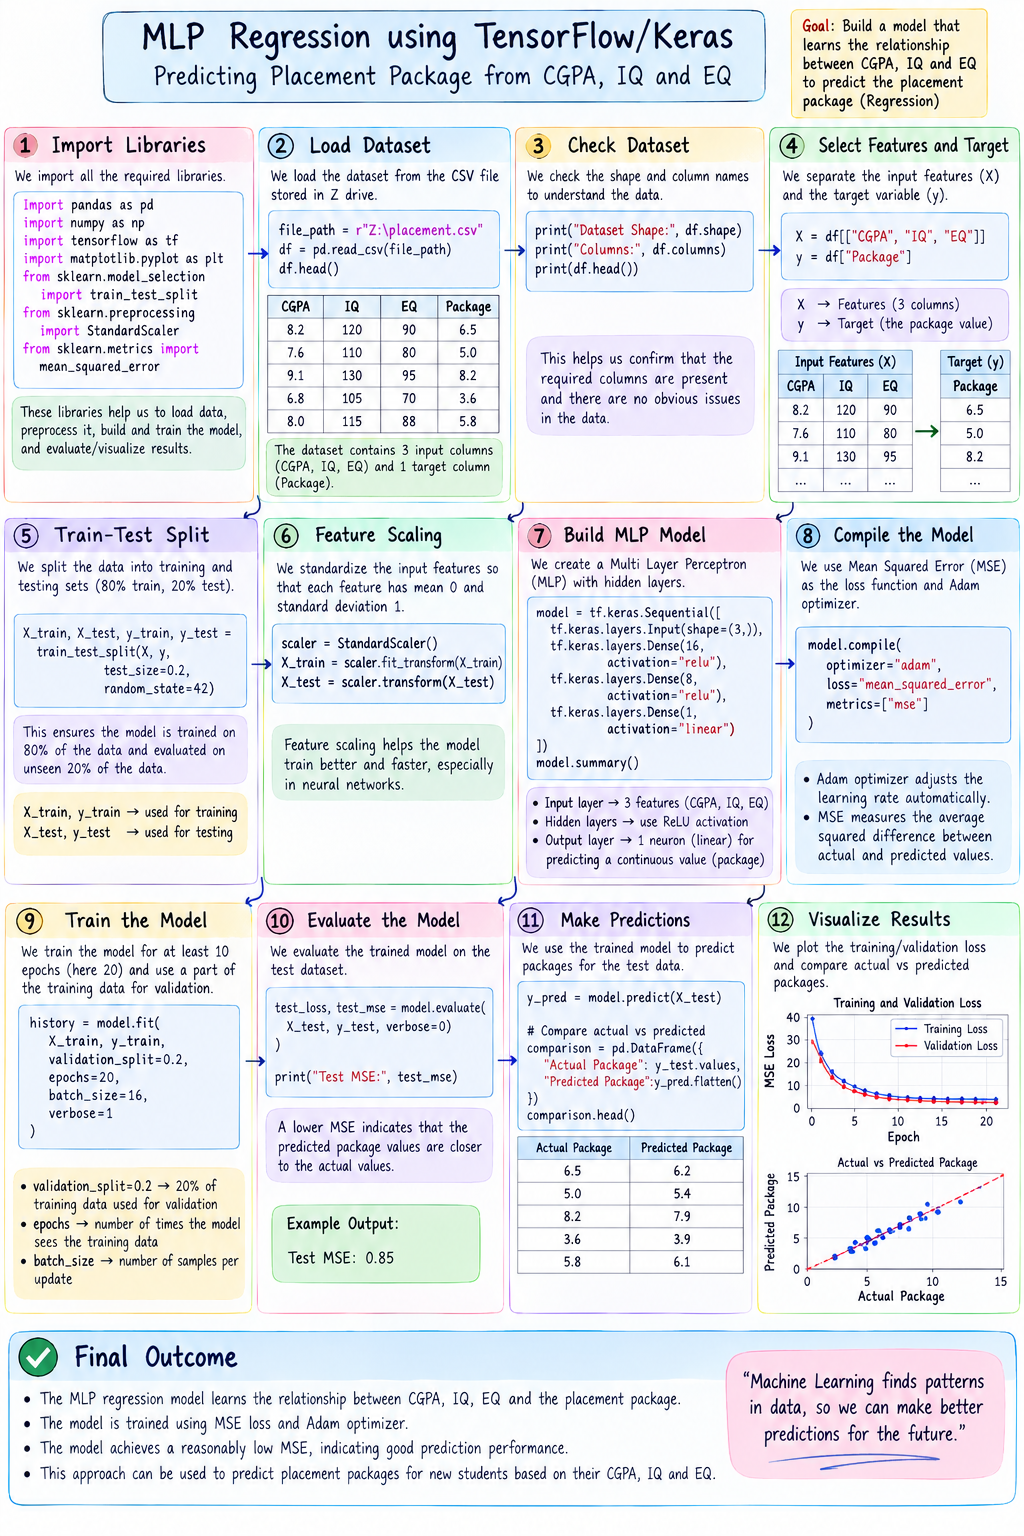